# Probabilité que le SIRET proposé par l'ANS soit retenu

Objectif : estimer dans quels cas le SIRET proposé par l'ANS est suffisamment fiable pour être utilisé automatiquement.

J'utilise une régression logistique pondérée, avec une ligne par EGE.

- *À rapprocher* = tous les EGE sauf ceux à fermer (`Incertitude1 = -1`, `-2` ou `-12`).
- Le modèle est estimé uniquement sur les EGE pour lesquels l'ANS propose un SIRET.
- `Y = 1` si la proposition ANS est le SIRET retenu, sinon `Y = 0`.
- Un SIRET retenu manquant compte donc comme `Y = 0`.
- Poids EGE = `Population size / EGEs examined` au sein de chaque strate.
- L'évaluation repose sur une validation croisée à 5 plis, groupée par EJ.

Les résultats sont présentés en deux temps : d'abord le comportement du score sur les EGE pour lesquels l'ANS fournit une proposition, puis l'application, propre à notre contexte, d'une règle **« ANS si le score dépasse le seuil, sinon Initial »** sur l'ensemble des EGE à rapprocher.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

review = pd.read_excel("data/ege_reviewed_sample.xlsx")
strata = pd.read_excel("data/ege_strata_plan_review_analysis.xlsx", sheet_name="analysis")

print(f"{review['EGE'].nunique()} EGE revus uniques chargés.")


916 EGE revus uniques chargés.


In [2]:
# 1) Construire une ligne par EGE à rapprocher, puis l'échantillon de modélisation ANS

# EGE à fermer
close_by_ege = review.groupby("EGE")["Incertitude1"].apply(
    lambda x: x.isin([-1, -2, -12]).any()
)

to_match_eges = close_by_ege.index[~close_by_ege]
to_match = review[review["EGE"].isin(to_match_eges)].copy()

# Décision retenue au niveau EGE
retained = (
    to_match.groupby("EGE", as_index=False)["Siret_retenu"]
    .first()
    .rename(columns={"Siret_retenu": "retained_siret"})
)

# SIRET Initial : exactement une ligne Initial par EGE dans les propositions
initial = (
    to_match.loc[to_match["is_initial_siret"].eq(True), ["EGE", "siret_proposal"]]
    .rename(columns={"siret_proposal": "initial_siret"})
)
assert initial["EGE"].is_unique

# Contexte EGE/EJ et strate : une valeur unique par EGE
entity_context = (
    to_match.groupby("EGE", as_index=False)
    .agg({"stratum_id": "first", "EJ": "first"})
)

entities = (
    entity_context
    .merge(retained, on="EGE", how="left")
    .merge(initial, on="EGE", how="left")
    .merge(
        strata[["Stratum ID", "Population size", "EGEs examined"]],
        left_on="stratum_id",
        right_on="Stratum ID",
        how="left",
    )
)
entities["weight"] = entities["Population size"] / entities["EGEs examined"]

# Même définition qu'en étape 05 : deux identifiants manquants sont cohérents entre eux.
entities["initial_correct"] = (
    (entities["initial_siret"].isna() & entities["retained_siret"].isna())
    | (
        entities["initial_siret"].notna()
        & entities["retained_siret"].notna()
        & entities["initial_siret"].eq(entities["retained_siret"])
    )
).astype(int)

# Garder l'unique proposition ANS pour le modèle
ans_rows = to_match[to_match["proposal_source"].isin(["ANS", "both"])].copy()
assert ans_rows["EGE"].is_unique

model = ans_rows.merge(
    entities[["EGE", "retained_siret", "weight"]],
    on="EGE",
    how="left",
)

# Variable cible
model["Y"] = (
    model["retained_siret"].notna()
    & model["siret_proposal"].eq(model["retained_siret"])
).astype(int)

weighted_rate = np.average(model["Y"], weights=model["weight"])
ans_coverage = model["weight"].sum() / entities["weight"].sum()
initial_rate = np.average(entities["initial_correct"], weights=entities["weight"])

print(f"Total EGE revus :                       {review['EGE'].nunique():>4}")
print(f"EGE à fermer :                          {int(close_by_ege.sum()):>4}")
print(f"EGE à rapprocher :                      {len(entities):>4}")
print(f"EGE à rapprocher avec ANS :             {len(model):>4}")
print(f"Couverture ANS pondérée :               {ans_coverage:.1%}")
print(f"Propositions ANS correctes :            {model['Y'].sum():>4} / {len(model)}")
print(f"SIRET retenu manquant :                 {model['retained_siret'].isna().sum():>4}  (tous Y=0)")
print(f"Taux de réussite ANS pondéré :          {weighted_rate:.3f}")
print(f"Taux de réussite Initial pondéré :      {initial_rate:.3f}")

Total EGE revus :                        916
EGE à fermer :                            21
EGE à rapprocher :                       895
EGE à rapprocher avec ANS :              687
Couverture ANS pondérée :               87.6%
Propositions ANS correctes :             441 / 687
SIRET retenu manquant :                   27  (tous Y=0)
Taux de réussite ANS pondéré :          0.854
Taux de réussite Initial pondéré :      0.660


In [3]:
# 2) Petite régression logistique pondérée + validation croisée groupée à 5 plis

coh = "coherence_siren_du_siret_avec_siren_ej_corrige"

model["Initial SIRET = yes"] = model["is_initial_siret"].eq(True).astype(int)
model["SIREN coherent = yes"] = model[coh].eq(True).astype(int)
model["SIREN coherence = missing"] = model[coh].isna().astype(int)
model["ANS status = VALIDE_FORT"] = model["statut_EGE_ANS"].eq("VALIDE_FORT").astype(int)
model["Datasets = total consistency"] = model["datasets_consistency_EGE"].eq("Total consistency").astype(int)
model["Datasets = partial consistency"] = model["datasets_consistency_EGE"].eq("Partial consistency").astype(int)

features = [
    "Initial SIRET = yes",
    "SIREN coherent = yes",
    "SIREN coherence = missing",
    "ANS status = VALIDE_FORT",
    "Datasets = total consistency",
    "Datasets = partial consistency",
]

X = sm.add_constant(model[features], has_constant="add").to_numpy(dtype=float)
y = model["Y"].to_numpy()
w = model["weight"].to_numpy(dtype=float)
groups = model["EJ"].fillna(model["EGE"]).astype(str).to_numpy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2026)
splits = list(cv.split(X, y, groups))
oof = np.full(len(model), np.nan)

for train, test in splits:
    fit = sm.GLM(
        y[train], X[train],
        family=sm.families.Binomial(),
        freq_weights=w[train] / w[train].mean(),
    ).fit()
    oof[test] = fit.predict(X[test])

brier = np.average((y - oof) ** 2, weights=w)
baseline_brier = np.average((y - weighted_rate) ** 2, weights=w)
auc = roc_auc_score(y, oof, sample_weight=w)
mean_pred = np.average(oof, weights=w)

print(f"Score de Brier pondéré : {brier:.3f}   (référence constante : {baseline_brier:.3f})")
print(f"AUC ROC pondérée :       {auc:.3f}")
print(f"Observé vs score moyen : {weighted_rate:.3f} vs {mean_pred:.3f}")


Score de Brier pondéré : 0.061   (référence constante : 0.125)
AUC ROC pondérée :       0.910
Observé vs score moyen : 0.854 vs 0.848


### Pourquoi garder un modèle simple ?

L'échantillon de modélisation contient 687 EGE, les poids sont inégaux et plusieurs variables apportent des informations proches. Je pars donc de quelques prédicteurs disponibles avant la revue et faciles à interpréter, plutôt que d'inclure toutes les variables disponibles dans la régression.

Je vérifie ensuite si l'ajout d'un prédicteur améliore suffisamment les performances hors-échantillon pour justifier de le conserver.


### Pourquoi une validation croisée ?

Avec seulement 687 EGE dans l'échantillon de modélisation, je préfère ne pas réserver une grande partie des observations à un unique jeu de test.

Avec une validation croisée à 5 plis, chaque EGE reçoit une prédiction issue d'un modèle qui n'a pas été ajusté sur cet EGE. J'utilise ces prédictions *out-of-fold* pour calculer le score de Brier, l'AUC, la calibration et les résultats selon les seuils.

Les plis sont groupés par EJ afin que des EGE appartenant à la même EJ ne soient pas répartis entre apprentissage et validation.


In [4]:
# 3) Ajustement final sur tous les EGE éligibles

final_fit = sm.GLM(
    y, X,
    family=sm.families.Binomial(),
    freq_weights=w / w.mean(),
).fit()

feature_names = ["Intercept"] + features

print("Référence : initial=no ; SIREN coherence=false ; status=VALIDE ; datasets=total inconsistency.")
print()
print(f'{"Terme":36s} {"Coef.":>9s} {"Odds ratio":>12s}')
print("-" * 61)
for name, coef in zip(feature_names, final_fit.params):
    print(f"{name:36s} {coef:9.3f} {np.exp(coef):12.2f}")


Référence : initial=no ; SIREN coherence=false ; status=VALIDE ; datasets=total inconsistency.

Terme                                    Coef.   Odds ratio
-------------------------------------------------------------
Intercept                               -1.115         0.33
Initial SIRET = yes                      0.384         1.47
SIREN coherent = yes                     4.141        62.89
SIREN coherence = missing                1.960         7.10
ANS status = VALIDE_FORT                 1.182         3.26
Datasets = total consistency             0.843         2.32
Datasets = partial consistency          -4.746         0.01


### Effet des prédicteurs

Les *odds ratios* sont ajustés : chaque effet s'interprète à valeurs constantes des autres variables du modèle.

Référence : initial SIRET = no ; SIREN coherence = false ; ANS status = `VALIDE` ; datasets = total inconsistency.

- `SIREN coherent = yes` : **OR 62,89** — de loin le prédicteur positif le plus fort.
- `ANS status = VALIDE_FORT` : **OR 3,26** — augmente nettement les chances que la proposition ANS soit correcte.
- `Datasets = total consistency` : **OR 2,32** — l'accord entre les jeux de données augmente aussi la confiance.
- `Initial SIRET = yes` : **OR 1,47** — effet positif plus modéré.
- `Datasets = partial consistency` : **OR ≈ 0,01** — association fortement négative, mais cette catégorie ne contient que 38 EGE.
- `SIREN coherence = missing` : **OR 7,10**, mais l'estimation repose sur seulement 9 EGE et doit donc être interprétée avec prudence.

`datasets_consistency_EGE` est utile ici car cette variable conserve aussi une information sur la proposition d'Adrien.

**Limite de transposition en production** : La cohérence du SIREN est calculée ici avec le SIREN EJ corrigé issu de la revue EJ. En production, ce SIREN ne serait pas disponible : il faudrait utiliser le SIREN obtenu à l'issue de la sirénisation EJ. S'il est de bonne qualité, l'information devrait rester proche, mais les performances présentées ici sont probablement un peu optimistes et devront être réévaluées avec un SIREN EJ produit dans des conditions de production.

In [4]:
# 4) Tester le cinquième prédicteur discuté : coherence_EGE_ANS

# Ajout comme variable catégorielle, avec "Incohérent" comme référence
model["EGE coherence = coherent"] = model["coherence_EGE_ANS"].eq("Cohérent").astype(int)
model["EGE coherence = alone"] = model["coherence_EGE_ANS"].eq("EGE seul").astype(int)

extended_features = features + [
    "EGE coherence = coherent",
    "EGE coherence = alone",
]

X_extended = sm.add_constant(model[extended_features], has_constant="add").to_numpy(dtype=float)
oof_extended = np.full(len(model), np.nan)

for train, test in splits:
    fit_extended = sm.GLM(
        y[train], X_extended[train],
        family=sm.families.Binomial(),
        freq_weights=w[train] / w[train].mean(),
    ).fit()
    oof_extended[test] = fit_extended.predict(X_extended[test])

comparison = pd.DataFrame({
    "Modèle": ["Modèle final", "+ coherence_EGE_ANS"],
    "Brier pondéré": [
        np.average((y - oof) ** 2, weights=w),
        np.average((y - oof_extended) ** 2, weights=w),
    ],
    "AUC pondérée": [
        roc_auc_score(y, oof, sample_weight=w),
        roc_auc_score(y, oof_extended, sample_weight=w),
    ],
})

print(comparison.to_string(index=False, formatters={
    "Brier pondéré": "{:.5f}".format,
    "AUC pondérée": "{:.5f}".format,
}))


             Modèle Brier pondéré AUC pondérée
       Modèle final       0.06084      0.91009
+ coherence_EGE_ANS       0.06037      0.90849


### Pourquoi ne pas garder `coherence_EGE_ANS` ?

Je l'ai testée comme prédicteur supplémentaire.

- Score de Brier : **0,06084 → 0,06037**
- AUC : **0,91009 → 0,90849**

Le gain sur le score de Brier est inférieur à 0,001 et l'AUC diminue légèrement. Je ne la conserve donc pas. Cette variable contient de l'information, mais elle apporte très peu une fois les autres prédicteurs déjà présents dans le modèle.


Classe     n     Prédit    Observé
     1   120      0.111      0.330
     2   152      0.297      0.123
     3   140      0.941      0.900
     4   131      0.979      0.992
     5   144      0.996      0.978


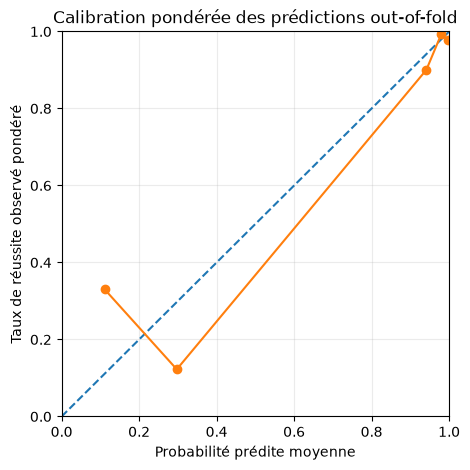

In [5]:
# 5) Calibration pondérée des probabilités out-of-fold

edges = np.quantile(oof, [0, .2, .4, .6, .8, 1])
cal = []

for j in range(5):
    if j < 4:
        mask = (oof >= edges[j]) & (oof < edges[j + 1])
    else:
        mask = (oof >= edges[j]) & (oof <= edges[j + 1])

    cal.append((
        np.average(oof[mask], weights=w[mask]),
        np.average(y[mask], weights=w[mask]),
        int(mask.sum()),
    ))

print(f'{"Classe":>6s} {"n":>5s} {"Prédit":>10s} {"Observé":>10s}')
for i, (pred, obs, n) in enumerate(cal, 1):
    print(f"{i:>6d} {n:>5d} {pred:>10.3f} {obs:>10.3f}")

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--")
plt.plot([x[0] for x in cal], [x[1] for x in cal], marker="o")
plt.xlabel("Probabilité prédite moyenne")
plt.ylabel("Taux de réussite observé pondéré")
plt.title("Calibration pondérée des prédictions out-of-fold")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=.25)
plt.show()


In [6]:
# 6) Résultats du modèle selon le seuil : uniquement parmi les EGE avec une proposition ANS

thresholds = [0.50, 0.80, 0.90, 0.95, 0.97]
model = model.copy()
model["oof_score"] = oof

rows = []
for threshold in thresholds:
    accepted = model["oof_score"].ge(threshold)
    rejected = ~accepted

    accepted_weight = model.loc[accepted, "weight"].sum()
    ans_weight = model["weight"].sum()

    correct_accepted = np.average(
        model.loc[accepted, "Y"],
        weights=model.loc[accepted, "weight"],
    )

    rows.append({
        "Seuil": threshold,
        "Part des EGE avec ANS acceptée": accepted_weight / ans_weight,
        "Correct parmi les ANS acceptés": correct_accepted,
        "Incorrect parmi les ANS acceptés": 1 - correct_accepted,
        "Correct parmi les ANS rejetés": np.average(
            model.loc[rejected, "Y"],
            weights=model.loc[rejected, "weight"],
        ),
    })

threshold_results_model = pd.DataFrame(rows)

display(
    threshold_results_model.style.format({
        "Seuil": "{:.2f}",
        "Part des EGE avec ANS acceptée": "{:.1%}",
        "Correct parmi les ANS acceptés": "{:.1%}",
        "Incorrect parmi les ANS acceptés": "{:.1%}",
        "Correct parmi les ANS rejetés": "{:.1%}",
    })
)


,Seuil,Part des EGE avec ANS acceptée,Correct parmi les ANS acceptés,Incorrect parmi les ANS acceptés,Correct parmi les ANS rejetés
0,0.50,83.6%,97.0%,3.0%,26.5%
1,0.80,83.2%,97.2%,2.8%,26.7%
2,0.90,82.0%,98.4%,1.6%,26.2%
3,0.95,79.0%,98.3%,1.7%,36.7%
4,0.97,66.5%,98.4%,1.6%,59.6%


### Lecture des résultats du modèle

Cette première lecture porte uniquement sur les EGE pour lesquels l'ANS fournit une proposition. Elle répond à la question : **quelle part de ces propositions peut être acceptée à un seuil donné, et avec quelle précision ?**

Avec un seuil de **0,90** :

- **82,0 % des EGE disposant d'une proposition ANS** dépassent le seuil ;
- parmi les propositions ANS ainsi acceptées, **98,4 %** sont correctes et **1,6 %** sont incorrectes ;
- parmi les propositions ANS sous le seuil, environ **26,2 %** sont néanmoins correctes.

Les autres indicateurs de performance du modèle sont également bons : score de Brier pondéré de **0,061**, contre **0,125** pour un modèle à probabilité constante, et AUC pondérée de **0,910**.

Le score sert donc surtout à isoler un groupe de propositions ANS à très forte confiance. Cette lecture ne dit pas encore ce qu'il faut faire des EGE sans proposition ANS ni des propositions situées sous le seuil.


In [7]:
# 7) Application à notre contexte : ANS au-dessus du seuil, Initial sinon

entity_eval = entities.merge(
    model[["EGE", "Y", "oof_score"]],
    on="EGE",
    how="left",
)

initial_rate = np.average(
    entity_eval["initial_correct"],
    weights=entity_eval["weight"],
)
ans_coverage = model["weight"].sum() / entity_eval["weight"].sum()

plain_ans_fallback_correct = np.where(
    entity_eval["oof_score"].notna(),
    entity_eval["Y"].fillna(0),
    entity_eval["initial_correct"],
)
plain_ans_fallback_rate = np.average(
    plain_ans_fallback_correct,
    weights=entity_eval["weight"],
)

rows = []
for threshold in thresholds:
    use_ans = entity_eval["oof_score"].ge(threshold).fillna(False)

    deployed_correct = np.where(
        use_ans,
        entity_eval["Y"].fillna(0),
        entity_eval["initial_correct"],
    )
    fallback_rate = np.average(
        deployed_correct,
        weights=entity_eval["weight"],
    )

    treated_by_ans = (
        entity_eval.loc[use_ans, "weight"].sum()
        / entity_eval["weight"].sum()
    )

    rows.append({
        "Seuil": threshold,
        "Part de tous les EGE traitée par ANS": treated_by_ans,
        "Correct — ANS si score ≥ seuil, sinon Initial": fallback_rate,
        "Gain vs Initial (pp)": 100 * (fallback_rate - initial_rate),
        "Gain vs ANS sinon Initial (pp)": 100 * (
            fallback_rate - plain_ans_fallback_rate
        ),
    })

threshold_results_rule = pd.DataFrame(rows)

print(f"Couverture ANS parmi tous les EGE à rapprocher : {ans_coverage:.1%}")
print(f"Initial seul — taux correct :                    {initial_rate:.1%}")
print(f"ANS sinon Initial — taux correct :               {plain_ans_fallback_rate:.1%}")
print()

display(
    threshold_results_rule.style.format({
        "Seuil": "{:.2f}",
        "Part de tous les EGE traitée par ANS": "{:.1%}",
        "Correct — ANS si score ≥ seuil, sinon Initial": "{:.1%}",
        "Gain vs Initial (pp)": "{:+.1f}",
        "Gain vs ANS sinon Initial (pp)": "{:+.1f}",
    })
)


Couverture ANS parmi tous les EGE à rapprocher : 87.6%
Initial seul — taux correct :                    66.0%
ANS sinon Initial — taux correct :               80.3%



,Seuil,Part de tous les EGE traitée par ANS,"Correct — ANS si score ≥ seuil, sinon Initial",Gain vs Initial (pp),Gain vs ANS sinon Initial (pp)
0,0.50,73.2%,82.5%,+16.4,+2.1
1,0.80,72.9%,82.5%,+16.5,+2.2
2,0.90,71.9%,82.4%,+16.4,+2.1
3,0.95,69.2%,79.9%,+13.9,-0.4
4,0.97,58.3%,76.6%,+10.6,-3.7


## Application de la règle dans notre contexte

Le logit ne s'applique qu'aux EGE pour lesquels l'ANS fournit une proposition. Après pondération, l'ANS couvre **87,6 %** de l'ensemble des EGE à rapprocher. Pour évaluer une règle complète, il faut donc préciser le traitement des autres cas.

Avec un seuil de **0,90**, si l'on utilise la proposition ANS uniquement au-dessus du seuil et que l'on conserve **Initial** dans tous les autres cas :

- **71,9 % de l'ensemble des EGE à rapprocher** sont traités avec la proposition ANS ;
- la règle **« ANS si score ≥ 0,90, sinon Initial »** atteint un taux estimé de résultats corrects de **82,4 %** ;
- **Initial seul** atteint **66,0 %** ;
- **ANS sinon Initial**, sans sélection par le logit, atteint **80,3 %**.

Le seuil de 0,90 apporte ainsi environ **+16,4 points** par rapport à Initial et **+2,1 points** par rapport à l'utilisation systématique de la proposition ANS lorsqu'elle existe.

Cette seconde partie est spécifique à la règle de repli choisie pour notre contexte ; elle ne constitue pas une mesure intrinsèque de la qualité de la régression logistique.

Les résultats reposent sur des prédictions *out-of-fold*, mais restent une validation interne sur l'échantillon de revue. Ils sont en outre probablement un peu optimistes pour une utilisation en production, car le modèle utilise la cohérence avec le SIREN EJ corrigé par la revue ; en production, il faudrait remplacer cette information par le SIREN issu de la sirénisation EJ et réévaluer les performances.
